# Darstellung von Messdaten der Campbell-Klimastation in Gülpe

>Do you remember
>
>The 21st night of September?
>
>Love was changin' the minds of pretenders
>
>While chasin' the clouds away

(September by Earth, Wind & Fire, 1978)

### Hintergrund

In diesem Jupyter-Notebook werden die Klimadaten der Station in Gülpe erklärt und exemplarisch mit Hilfe der Programmiersprache Python dargestellt. Ihr könnt in diesem Notebook nach belieben manipulieren, es wird nichts gespeichert. Achtung: Wenn Ihr längere Zeit nichts tut, erlischt die Umgebung. Ihr könnt das Notebook aber über `File > Download` auf Euren lokalen Rechner herunterladen und dieses wiederum über das Upload-Button auch hochladen. 

Macht Euch keine Sorgen, wenn Ihr kein Python beherrscht: ChatGPT & Co können dies sehr gut und helfen Euch. Nutzt dafür gern die Plattform der Uni Potsdam:  https://gptup.uni-potsdam.de

### Hello world!

Eure erste Amtshandlung in einer Programmiersprache: Die Hello-World-Anwendung. In der folgenden Zelle befindet sich der Programmcode. Ihr führt den Code über das Play-Button (Werkzeugleiste oben) aus.

In [ ]:
print("Hello world!")

### Import benötigter Python-Pakete

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

### Dateien

Die folgenden Dateien werden (meistens mit der Endung `.dat`) beim Auslesen der Klimastation  bereitgestellt. Es handelt sich um Tabellen im Textformat, sogenannte "csv"-Dateien.  (**c**omma **s**eperated **v**alues). 
- `*Regen*.*`: Niederschlag
- `*Strahlung*.*`: Strahlung (kurzwellig/langwellig von oben/unten, Nettostrahlung als berechnete Größe)
- `*Temp*.*`: Lufttemperatur und relative Luftfeuchte in 50 und 200 cm Höhe, Bodentemperatur in 5, 20 und 50 cm Tiefe.
- `*Wind*.*`: Windgeschwindigkeit und Windrichtung
- `*BF*.*`: Bodenfeuchte (tatsächlich wird aber nicht direkt die Bodenfeuchte gemessen, sondern ein Spannungssignal, aus dem zunächst die Permittivität und dann die Bodenfeuchte ermittelt wird)
- `*DK*.*`: Dielektrizität / Permittivität?
- `*Pegel*.*`: Grundwasserstand und Grundwassertemperatur?

Für Euch sind zunächst nur die Dateien `Regen`, `Strahlung`, `Wind` und `Temp` relevant bzw. interessant. Ihr bekommt einen Eindruck von der Struktur der Daten, wenn Ihr sie mit einem Texteditor wie zum Beispiel notepad++ öffnet.

Die ersten vier Zeilen enthalten Informationen über die einzelnen Spalten
1. Zeile: Metadaten, z.B. zum Format, zur Station und zum Sensor
2. Zeile: Variablenname
3. Zeile: physikalische Einheit
4. Zeile: Angabe, ob es sich um Instantan- oder Mittelwerte handelt. Typischerweise handelt es sich um Mittelwerte ("Avg"), da der Logger eigentlich viel häufiger (z.B. sekündlich) misst als Daten ausgegeben werden (Ausgabeintervall typischerweise 5 oder 20 Minuten).

### Variablen

| Spaltenname               | Bedeutung                                           | Einheit                   | Vermutlicher Sensor                            |
| ------------------------- | --------------------------------------------------- | ------------------------- | ---------------------------------------------- |
| `AirTC_1_Avg`    | Lufttemperatur in 200 cm               | °C                        | Temperatur-/Feuchtesensor (z.B. HMP155, HC2S3) |
| `RH_1`           | Relative Luftfeuchte in 200 cm                     | %                         | gleicher Sensor                                |
| `AirTC_2_Avg`    | Lufttemperatur in 50 cm                           | °C                        | zweiter Temperatur-/Feuchtesensor              |
| `RH_2`           | Relative Luftfeuchte in 50 cm                     | %                         | zweiter Sensor                                 |
| `T107_C_1_Avg`        | Bodentemperatur in 5 cm Tiefe                       | °C                        | Campbell T107 Thermistor                       |
| `T107_C_2_Avg`        | Bodentemperatur in 20 cm Tiefe                       | °C                        | T107                                           |
| `T107_C_3_Avg`        | Bodentemperatur in 50 cm Tiefe                       | °C                        | T107                                           |
| `WS.ms.S.WVT.Wvc`         | Windgeschwindigkeit in 200 cm         | m s⁻¹                     | Windmonitor (z.B. RM Young)                    |
| `wind.dir.d1.deg.WVT.Wvc` | Windrichtung in 200 cm                | °                         | Windmonitor                                    |
| `WSDiag.smp`              | Diagnosecode des Windsensors                        | -                         | Windmonitor                                    |
| `SUp_Avg`            | Kurzwellige Strahlung nach unten (Globalstrahlung)                       | W m⁻²                     | CNR4                                           |
| `SDn_Avg`            | Kurzwellige Strahlung nach oben      | W m⁻²                     | CNR4                                           |
| `LUp_Avg`            | Langwellige Strahlung nach oben                       | W m⁻²                     | CNR4                                           |
| `LDn_Avg`            | Langwellige Strahlung nach unten                        | W m⁻²                     | CNR4                                           |
| `CNR4TC_Avg`        | Gehäusetemperatur des CNR4                          | °C                        | CNR4                                           |
| `CNR4TK_Avg`            | Gehäusetemperatur des CNR4                          | K                         | CNR4                                           |
| `RsNet_Avg`          | Netto-Kurzwellensaldo = SUp − SDn                   | W m⁻²                     | berechnet                                      |
| `RlNet_Avg`          | Netto-Langwellensaldo = LDn − LUp                   | W m⁻²                     | berechnet                                      |
| `Albedo_Avg`         | Albedo=SUp/SDn (nur tagsüber)          | - | berechnet                                      |
| `Rn_Avg`             | Netto-Strahlungsbilanz                              | W m⁻²                     | berechnet                                      |
| `LUpCo_Avg`          | Temperaturkorrigierte langwellige Aufwärtsstrahlung | W m⁻²                     | CNR4                                           |
| `LDnCo_Avg`          | Temperaturkorrigierte langwellige Abwärtsstrahlung  | W m⁻²                     | CNR4                                           |
| `Rain_mm_Tot`             | Niederschlagssumme                                  | mm                        | Kippwaage                                      |


#### Dateien lesen, Variablen plotten

Wir arbeiten hier mit Beispieldaten vom 31. August 2026. Ihr könnt andere Daten über das Upload-Button in das Verzeichnis `daten` hochladen. Achtung: Wenn Ihr die Umgebung schließt, ist das futsch.

In [22]:
# Kleine Helferfunktion, um die Dateien einzulesen...
def lies(dateipfad):
    df = pd.read_csv(dateipfad, skiprows=[0,2,3])
    df["datetime"] = pd.to_datetime(df.TIMESTAMP)
    df = df.set_index("datetime")
    df = df.drop(columns=["TIMESTAMP","RECORD"])
    return df

In [23]:
# Temperatur
temp = lies("daten/20260831-campbell/CR1000_Gülpe_CELL2015_Temp.dat")
# Strahlung
rad = lies("daten/20260831-campbell/CR1000_Gülpe_CELL2015_Strahlung.dat")
# Wind
wind = lies("daten/20260831-campbell/CR1000_Gülpe_CELL2015_Wind.dat")
# Niederschlag
nd = lies("daten/20260831-campbell/CR1000_Gülpe_CELL2015_Regen.dat")

#### Temperatur

In [27]:
temp

,AirTC_1_Avg,RH_1,AirTC_2_Avg,RH_2,T107_C_1_Avg,T107_C_2_Avg,T107_C_3_Avg
datetime,,,,,,,
2026-08-30 00:00:00,17.29,75.83,16.46,80.40,18.48,17.45,16.57
2026-08-30 00:20:00,18.62,67.67,17.72,71.35,18.42,17.46,16.58
2026-08-30 00:40:00,20.29,63.93,19.71,65.55,18.37,17.46,16.58
2026-08-30 01:00:00,20.56,64.27,20.13,65.52,18.31,17.46,16.58
2026-08-30 01:20:00,20.47,65.25,20.05,66.26,18.26,17.46,16.58
...,...,...,...,...,...,...,...
2026-08-31 12:40:00,24.50,57.41,26.55,51.66,17.81,17.26,16.67
2026-08-31 13:00:00,25.11,54.15,27.09,48.28,17.92,17.26,16.67
2026-08-31 13:20:00,24.98,59.55,26.68,56.43,18.03,17.24,16.66


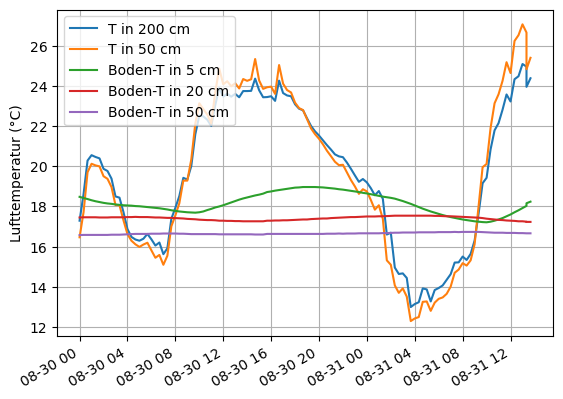

In [13]:
fig, ax = plt.subplots(1,1)
plt.plot(temp.index, temp["AirTC_1_Avg"], label="T in 200 cm")
plt.plot(temp.index, temp["AirTC_2_Avg"], label="T in 50 cm")
plt.plot(temp.index, temp["T107_C_1_Avg"], label="Boden-T in 5 cm")
plt.plot(temp.index, temp["T107_C_2_Avg"], label="Boden-T in 20 cm")
plt.plot(temp.index, temp["T107_C_3_Avg"], label="Boden-T in 50 cm")
plt.grid()
plt.legend()
plt.ylabel("Lufttemperatur (°C)")
fig.autofmt_xdate()

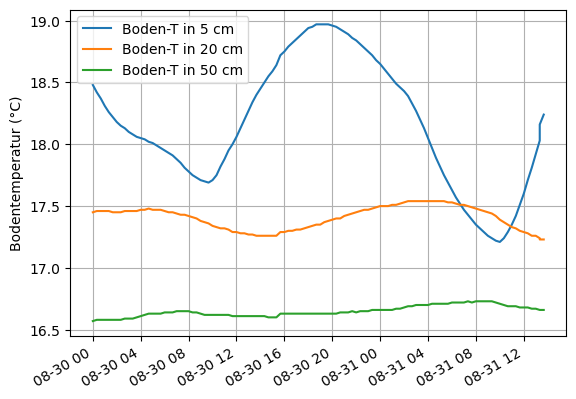

In [15]:
fig, ax = plt.subplots(1,1)
plt.plot(temp.index, temp["T107_C_1_Avg"], label="Boden-T in 5 cm")
plt.plot(temp.index, temp["T107_C_2_Avg"], label="Boden-T in 20 cm")
plt.plot(temp.index, temp["T107_C_3_Avg"], label="Boden-T in 50 cm")
plt.grid()
plt.legend()
plt.ylabel("Bodentemperatur (°C)")
fig.autofmt_xdate()

#### Strahlung

In [28]:
rad

,SUp_Avg,SDn_Avg,LUp_Avg,LDn_Avg,CNR4TC_Avg,CNR4TK_Avg,RsNet_Avg,RlNet_Avg,Albedo_Avg,Rn_Avg,LUpCo_Avg,LDnCo_Avg
datetime,,,,,,,,,,,,
2026-08-30 00:00:00,-0.309,1.573,-30.92,-6.638,16.72,289.9,-1.882,-24.28,NAN,-26.16,369.4,393.7
2026-08-30 00:20:00,0.303,2.951,-35.62,-6.915,17.66,290.8,-2.648,-28.70,NAN,-31.35,369.9,398.6
2026-08-30 00:40:00,0.605,2.698,-25.95,-5.907,19.51,292.7,-2.093,-20.05,NAN,-22.14,390.0,410.1
2026-08-30 01:00:00,-0.987,0.953,-30.80,-7.354,20.24,293.4,-1.940,-23.44,-1.067,-25.38,389.3,412.8
2026-08-30 01:20:00,-1.326,0.704,-31.99,-7.307,20.21,293.4,-2.030,-24.68,-0.616,-26.71,388.0,412.7
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-08-31 12:40:00,780.400,141.000,-71.80,48.620,27.47,300.6,639.400,-120.40,0.179,519.00,391.3,511.7
2026-08-31 13:00:00,802.000,146.800,-66.04,53.380,27.84,301.0,654.800,-119.40,0.181,535.40,399.3,518.8
2026-08-31 13:20:00,534.900,92.700,-61.52,39.560,28.48,301.6,442.300,-101.10,0.161,341.20,407.9,509.0


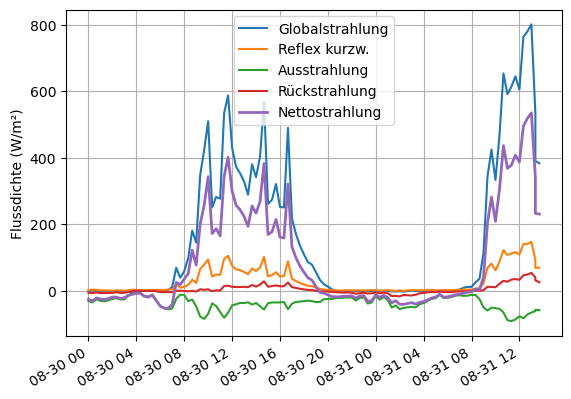

In [31]:
fig, ax = plt.subplots(1,1)
plt.plot(temp.index, rad["SUp_Avg"], label="Globalstrahlung")
plt.plot(temp.index, rad["SDn_Avg"], label="Reflex kurzw.")
plt.plot(temp.index, rad["LUp_Avg"], label="Ausstrahlung")
plt.plot(temp.index, rad["LDn_Avg"], label="Rückstrahlung")
plt.plot(temp.index, rad["Rn_Avg"], lw=2, label="Nettostrahlung")
plt.grid()
plt.legend()
plt.ylabel("Flussdichte (W/m²)")
fig.autofmt_xdate()

#### Wind

In [32]:
wind

,WS_ms_S_WVT,WindDir_D1_WVT,WSDiag
datetime,,,
2026-08-30 00:00:00,1.587,182.3,0
2026-08-30 00:20:00,2.311,194.5,0
2026-08-30 00:40:00,3.222,204.6,0
2026-08-30 01:00:00,3.416,204.2,0
2026-08-30 01:20:00,3.266,202.1,0
...,...,...,...
2026-08-31 12:40:00,4.652,199.1,0
2026-08-31 13:00:00,4.554,204.3,0
2026-08-31 13:20:00,2.897,241.1,0


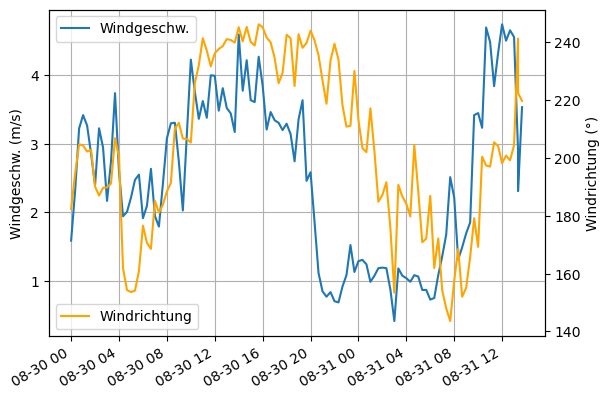

In [42]:
fig, ax = plt.subplots(1,1)
plt.plot(wind.index, wind["WS_ms_S_WVT"], label="Windgeschw.")
plt.ylabel("Windgeschw. (m/s)")
plt.legend(loc="upper left")
plt.grid()
ax2 = ax.twinx()
plt.plot(wind.index, wind["WindDir_D1_WVT"], color="orange", label="Windrichtung")
plt.ylabel("Windrichtung (°)")
plt.legend(loc="lower left")
fig.autofmt_xdate()

#### Niederschlag

In [43]:
nd

,Rain_mm_Tot
datetime,
2026-08-30 00:00:00,0.0
2026-08-30 00:05:00,0.0
2026-08-30 00:10:00,0.0
2026-08-30 00:15:00,0.0
2026-08-30 00:20:00,0.0
...,...
2026-08-31 13:35:00,0.0
2026-08-31 13:40:00,0.0
2026-08-31 13:45:00,0.0


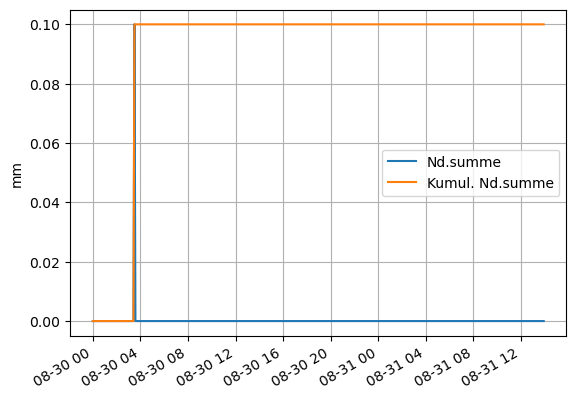

In [45]:
fig, ax = plt.subplots(1,1)
plt.plot(nd.index, nd["Rain_mm_Tot"], label="Nd.summe")
plt.plot(nd.index, nd["Rain_mm_Tot"].cumsum(), label="Kumul. Nd.summe")
plt.ylabel("mm")
plt.legend()
plt.grid()
fig.autofmt_xdate()